# **Mount my Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive




---



# **Script Start**

In [2]:
import numpy as np
import json
import os
import csv #[Hyosun]
import pandas as pd #[Hyosun]
import random       #[Hyosun]

# [Hyosun] confusion matrix
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt
# [/Hyosun] confusion matrix

In [3]:
def get_immediate_files(a_dir):
    return [name for name in os.listdir(a_dir) if os.path.isfile(os.path.join(a_dir, name))]

# **IurbanEvent**

In [4]:
# dataset downloaded from https://zenodo.org/records/1213793
# please change it to your IurbanEvent dataset path
# [Hyosun] current path: ./src/prep_data/IurbanEvent [/Hyosun]
event_path = './data/event_04s/'
#[Hyosun] use 11 labels
labels_arr = [#'bell',
              'bird', #'broom', #'carhorn',
              'citycar', #'citystep',
              'construction', #'coughing',
              'dog', #'doorbell', 'doorcar', 'doorhouse',
              'plane', 'roadcar', 'siren',
              'step', #[Hyosun] combined into one folder "step" from 'stepcity' and 'steppark'
              'stopcar', #'storm', #'streetnoise', 'suitcase',
              'train', #'tram',
              'truck'] #, 'voice']


In [5]:
cwd = os.getcwd()
print(cwd)

/content


In [6]:
os.chdir('/content/drive/MyDrive/hssast/src/finetune')
print(os.getcwd())
cur_dir = os.getcwd()

/content/drive/MyDrive/hssast/src/finetune


In [7]:
dataset_folder = '/Isolated_urbansound'

In [8]:
# /content/drive/MyDrive/hssast/src/finetune/Isolated_urbansound/exp/2023-12-20_iurbanevent/[success]13:07:03PM-test01-iurbanevent-comp_fusion-True-comp_fusion_method-use_all_patch-comp_fusion_multi_layer-[4,11]-pooling-max_max-comp_fusion_mlp6-loss-CE-f10-16-t10-16-b48-lr1e-4-ft_avgtok-base--SSAST-Base-Patch-400-1x-noiseTrue
result_dir = '2023-12-20_iurbanevent/[success]13:07:03PM-test01-iurbanevent-comp_fusion-True-' + \
                'comp_fusion_method-use_all_patch-comp_fusion_multi_layer-[4,11]-pooling-max_max-comp_fusion_mlp6-' + \
                'loss-CE-f10-16-t10-16-b48-lr1e-4-ft_avgtok-base--SSAST-Base-Patch-400-1x-noiseTrue'

In [9]:
os.chdir(cur_dir+dataset_folder+'/exp/'+ result_dir+'/')

In [10]:
cur_dir = os.getcwd()
print(cur_dir)

/content/drive/MyDrive/hssast/src/finetune/Isolated_urbansound/exp/2023-12-20_iurbanevent/[success]13:07:03PM-test01-iurbanevent-comp_fusion-True-comp_fusion_method-use_all_patch-comp_fusion_multi_layer-[4,11]-pooling-max_max-comp_fusion_mlp6-loss-CE-f10-16-t10-16-b48-lr1e-4-ft_avgtok-base--SSAST-Base-Patch-400-1x-noiseTrue


### **create the label description dictionary**

In [11]:
# [Hyosun: create the label description dictionary]
if os.path.exists('./../../../data/event_04s_class_labels_indices.csv') == True:
    label_set = np.loadtxt('./../../../data/event_04s_class_labels_indices.csv', delimiter=',', dtype='str')
    label_map = {}
    for i in range(1, len(label_set)):
        print("[Hyosun] label_set[i][0]: ", label_set[i][0])
        print("[Hyosun] label_set[i][2]: ", label_set[i][2])
        label_map[(label_set[i][2])] = label_set[i][0]
    print(label_map)
    print("[Hyosun] create the label description dictionary: using event_04s_class_labels_indices.csv finished!!")
#[/Hyosun: create the label description dictionary]

[Hyosun] label_set[i][0]:  0
[Hyosun] label_set[i][2]:  bird
[Hyosun] label_set[i][0]:  1
[Hyosun] label_set[i][2]:  citycar
[Hyosun] label_set[i][0]:  2
[Hyosun] label_set[i][2]:  construction
[Hyosun] label_set[i][0]:  3
[Hyosun] label_set[i][2]:  dog
[Hyosun] label_set[i][0]:  4
[Hyosun] label_set[i][2]:  plane
[Hyosun] label_set[i][0]:  5
[Hyosun] label_set[i][2]:  roadcar
[Hyosun] label_set[i][0]:  6
[Hyosun] label_set[i][2]:  siren
[Hyosun] label_set[i][0]:  7
[Hyosun] label_set[i][2]:  step
[Hyosun] label_set[i][0]:  8
[Hyosun] label_set[i][2]:  stopcar
[Hyosun] label_set[i][0]:  9
[Hyosun] label_set[i][2]:  train
[Hyosun] label_set[i][0]:  10
[Hyosun] label_set[i][2]:  truck
{'bird': '0', 'citycar': '1', 'construction': '2', 'dog': '3', 'plane': '4', 'roadcar': '5', 'siren': '6', 'step': '7', 'stopcar': '8', 'train': '9', 'truck': '10'}
[Hyosun] create the label description dictionary: using event_04s_class_labels_indices.csv finished!!


### **Average Precision**

In [21]:
import csv
if os.path.exists('./result.csv') == True:

    # [Hyosun] load avg precision (ind=2 at result.csv)
    results = np.loadtxt('./result.csv', delimiter=',', dtype='str')
    print("results[:,2]: \n", results[:,2])
    print("results[:,2].size: ", results[:,2].size)
    print("results[:,3]: \n", results[:,3])
    print("results[:,3].size: ", results[:,3].size)
    print("results.shape: ", results.shape)


results[:,2]: 
 ['4.997408151363961215e-01' '5.363697836969397725e-01'
 '5.548418972332016530e-01' '5.538537549407115401e-01'
 '5.625391477137736684e-01' '5.632411067193675569e-01'
 '5.600741916672066223e-01' '5.647233201581027817e-01'
 '5.671936758893280084e-01' '5.657114624505928946e-01'
 '5.637351778656126688e-01' '5.699610142767661536e-01'
 '5.704091881034147882e-01' '5.671936758893280084e-01'
 '5.684248039914469031e-01' '5.661729574773052276e-01'
 '5.694426445495582856e-01' '5.686758893280632332e-01'
 '5.694372448648998830e-01' '5.677282446705111951e-01'
 '5.681926175511349264e-01' '5.684194043067883895e-01'
 '5.676660296225513047e-01' '5.686596012682968437e-01'
 '5.671665291230507666e-01' '5.661675281240499125e-01'
 '5.662055335968378955e-01' '5.674663599645781709e-01'
 '5.664699401335181461e-01' '5.669830881876497530e-01'
 '5.664377200371497612e-01' '5.676877470355731203e-01'
 '5.669317911833948731e-01' '5.674285621719691308e-01'
 '5.671387790953007491e-01' '5.674635117792637962

epochs_arr:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44]


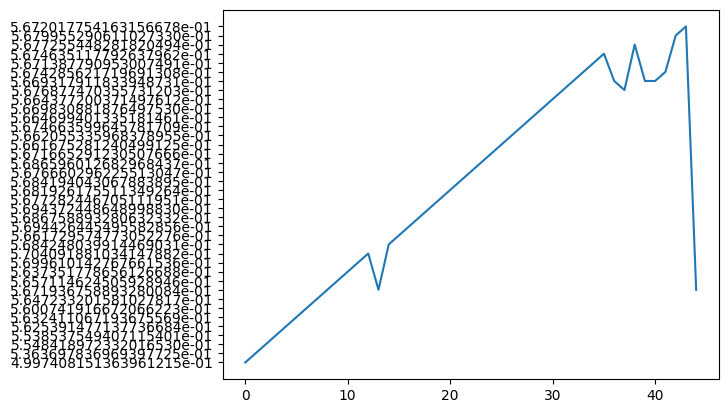

In [20]:
#plot AP
epochs_arr = [i for i in range(0, results[:,2].size)]
print("epochs_arr: ", epochs_arr)
plt.plot(epochs_arr, results[:,2])

### **Average Recall**

epochs_arr:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44]


Text(0.5, 1.0, 'Average recall2023-12-20_iurbanevent/[success]13:07:03PM-test01-iurbanevent-comp_fusion-True-comp_fusion_method-use_all_patch-comp_fusion_multi_layer-[4,11]-pooling-max_max-comp_fusion_mlp6-loss-CE-f10-16-t10-16-b48-lr1e-4-ft_avgtok-base--SSAST-Base-Patch-400-1x-noiseTrue')

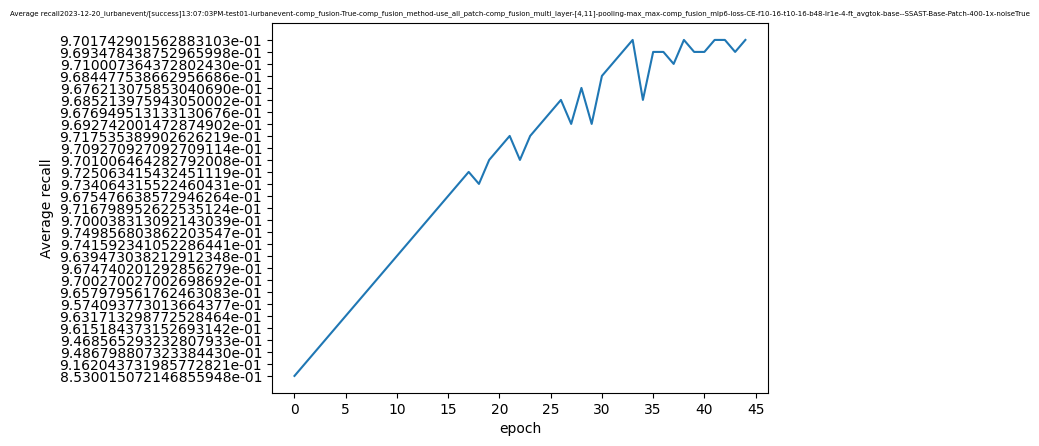

In [48]:
#plot avg recall
epochs_arr = [i for i in range(0, results[:,3].size)]
print("epochs_arr: ", epochs_arr)
plt.plot(epochs_arr, results[:,3])
# plt.legend()
# plt.xticks(rotation=45)
plt.xticks(np.arange(0, results[:,3].size+1, 5)) #[Hyosun]results[:,3].size+1 해서 마지막 epoch 보이게
# avg_recall=np.max(results[:,3])
# plt.yticks(np.arange(0, np.max(results[:,3]), 5), rotation=45)
plt.xlabel('epoch')
plt.ylabel('Average recall')
plt.title('Average recall'+result_dir, fontdict={'fontsize': 5}, loc='center', )

In [46]:
(results[:,3])

array(['8.530015072146855948e-01', '9.162043731985772821e-01',
       '9.486798807323384430e-01', '9.468565293232807933e-01',
       '9.615184373152693142e-01', '9.631713298772528464e-01',
       '9.574093773013664377e-01', '9.657979561762463083e-01',
       '9.700270027002698692e-01', '9.674740201292856279e-01',
       '9.639473038212912348e-01', '9.741592341052286441e-01',
       '9.749856803862203547e-01', '9.700038313092143039e-01',
       '9.716798952622535124e-01', '9.675476638572946264e-01',
       '9.734064315522460431e-01', '9.725063415432451119e-01',
       '9.734064315522460431e-01', '9.701006464282792008e-01',
       '9.709270927092709114e-01', '9.717535389902626219e-01',
       '9.701006464282792008e-01', '9.717535389902626219e-01',
       '9.692742001472874902e-01', '9.676949513133130676e-01',
       '9.685213975943050002e-01', '9.692742001472874902e-01',
       '9.676213075853040690e-01', '9.692742001472874902e-01',
       '9.684477538662956686e-01', '9.71000736437280243

- result.csv에 들어가는 10 column들 순서:
    - [acc, mAUC, average_precision, average_recall, d_prime(mAUC), loss_meter.avg, valid_loss, cum_acc, cum_mAUC, optimizer.param_groups[0]['lr']]


In [ ]:
        # if main_metrics == 'mAP':
        #     result[epoch-1, :] = [mAP, mAUC, average_precision, average_recall, d_prime(mAUC), loss_meter.avg, valid_loss, cum_mAP, cum_mAUC, optimizer.param_groups[0]['lr']]
        # else:
        #     result[epoch-1, :] = [acc, mAUC, average_precision, average_recall, d_prime(mAUC), loss_meter.avg, valid_loss, cum_acc, cum_mAUC, optimizer.param_groups[0]['lr']]
        # np.savetxt(exp_dir + '/result.csv', result, delimiter=',')
        # print('validation finished')